# GFTM B∥: do large-B∥ cases have bad growth rates, and does a 1/ky correction of the GFTM/GS2 B∥ ratio remove it? (Fusion_PhD-38e9.26)

Existing pyro objects only (GS2 `cube.nc` / `pyroscan.nc`, GFTM FILTER 0.5 leaves at WIDTH 0.4 and 0.8); no new runs.
Dominant mode = argmax γ over `mode` in each code. Per case, from the dominant mode's eigenfunction:

* r = peak|B∥| / peak|φ| (as `38e9.9`), and r₂ = (∫|B∥|²dθ / ∫|φ|²dθ)^½ as a robustness check; R = r_GFTM / r_GS2.
* e = log10(γ_GFTM / γ_GS2), and |Δγ|.

Populations: all GS2-unstable cases, and the GS2-KBM subset (`general_analysis.mode_classification.classify`, the user's
cutoffs in Fusion_PhD `docs/mode_filtering.md`). "Same mode" (for the ky fit): γ within ×1.5 and φ overlap > 0.85.

In [1]:
from pathlib import Path
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import NullFormatter
from scipy import stats
from scipy.integrate import trapezoid
from dotenv import load_dotenv
import pyrokinetics
from pyrokinetics import PyroHypercube, PyroScan
from general_analysis import mode_classification as mc

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)
warnings.filterwarnings("ignore")
print("pyrokinetics", pyrokinetics.__version__)

analysis_name = "gftm_bpar_ratio"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
plot_dir = ROOT / "Plots" / analysis_name
plot_dir.mkdir(parents=True, exist_ok=True)

hypercubes = ["SPR-045", "M1"]               # LATIN_HYPERCUBE/<db>/kbm_8d
beta_scans = ["R3", "R4", "M1_A1_NE"]        # scan_beta (GS2) / scan_beta_f05 (GFTM)
databases = hypercubes + beta_scans
widths = {0.4: ("wo_f05_w0p4000", "w0p4"), 0.8: ("wo_f05_w0p8000", "w0p8")}   # (hypercube leaf, beta-scan leaf)
gs2_tol = 0.1          # beta scans: drop GS2 cells with growth_rate_tolerance >= this (as 38e9.9); hypercubes use the tail average
same_gamma = 1.5       # same mode: gamma ratio within x1.5 ...
same_overlap = 0.85    # ... and |<phi_GFTM, phi_GS2>| above this
top = 0.75             # "large B_par" = top quartile within a database
fs_title, fs_label, fs_tick, fs_legend = 16, 16, 14, 12

pyrokinetics 0.9.2.dev149+gf119e687


## Load: GS2 reference and GFTM dominant mode, one row per case

In [2]:
def dominant(gamma, ef):
    "argmax gamma over the last (mode) axis; gamma 0 where GFTM has no unstable mode"
    gamma = np.nan_to_num(gamma, nan=-np.inf)
    dominant_mode = gamma.argmax(-1)
    gamma_dominant = np.take_along_axis(gamma, dominant_mode[..., None], -1)[..., 0]
    ef_dominant = np.take_along_axis(ef, dominant_mode[..., None, None, None], -1)[..., 0]
    return np.where(gamma_dominant > 0, gamma_dominant, 0.0), ef_dominant


def field_ratios(theta, ef):
    "peak and L2 |B_par|/|phi| of (case, field, theta) eigenfunctions; NaN padding counts as 0"
    values = np.abs(np.nan_to_num(ef))
    peak = values[:, 2].max(-1) / values[:, 0].max(-1)
    l2 = np.sqrt(trapezoid(values[:, 2] ** 2, theta, axis=-1) / trapezoid(values[:, 0] ** 2, theta, axis=-1))
    return peak, l2


def phi_overlap(th_s, phi_s, th_g, phi_g):
    "|<phi_GFTM, phi_GS2>| on GS2's theta grid; GFTM interpolated, zero outside its plot range"
    out = []
    for phi_gs2, phi_gftm in zip(np.nan_to_num(phi_s), phi_g):
        phi_gftm = np.interp(th_s, th_g, phi_gftm.real, left=0, right=0) + 1j * np.interp(th_s, th_g, phi_gftm.imag, left=0, right=0)
        inner = lambda values, other: abs(trapezoid(np.conj(values) * other, th_s))
        # ponytail: max over conjugation, so a sign convention for omega between codes cannot fake a mismatch
        out.append(max(inner(phi_gftm, phi_gs2), inner(np.conj(phi_gftm), phi_gs2)) / np.sqrt(inner(phi_gftm, phi_gftm) * inner(phi_gs2, phi_gs2)))
    return np.array(out)


def table(db, width, ky, beta, g_s, ef_s, th_s, label, keep, g_g, ef_g, th_g):
    "one row per kept case; all arrays are flattened over cases, ef as (case, field, theta)"
    peak_gs2, l2_gs2 = field_ratios(th_s, ef_s)
    peak_gftm, l2_gftm = field_ratios(th_g, ef_g)
    return pd.DataFrame(dict(db=db, width=width, ky=ky, beta=beta, g_gs2=g_s, g_gftm=g_g, kbm=label == "KBM",
                             r_gs2=peak_gs2, r_gftm=peak_gftm, r2_gs2=l2_gs2, r2_gftm=l2_gftm,
                             overlap=phi_overlap(th_s, ef_s[:, 0], th_g, ef_g[:, 0])))[keep]


def mag(da):
    return np.asarray(da.pint.dequantify().values)


rows = []
for db in hypercubes:
    base = data_root / "GS2" / "Runs" / "LATIN_HYPERCUBE" / db / "kbm_8d"
    gs2_scans = {}
    for cube in ("pyro_cube", "pyro_cube_avg"):   # final-time eigenfunctions / tail-averaged gamma (the hypercube reference)
        gs2_scans[cube] = PyroHypercube(pyroscan_json=base / cube / "pyroscan.json", load_base_pyro=True)
        mc.attach_legacy_funcs(gs2_scans[cube])   # this json predates parameter_func serialisation: re-attach the deck rules
        gs2_scans[cube].load_gk_output(netcdf_file=base / cube / "cube.nc")
    last, avg = gs2_scans["pyro_cube"].gk_output.data, gs2_scans["pyro_cube_avg"].gk_output.data
    label = np.asarray(mc.classify(mc.indicators(gs2_scans["pyro_cube"], last)))
    names = last.sample_name.values.astype(str)
    assert (avg.sample_name.values.astype(str) == names).all()
    g_s = mag(avg.growth_rate)
    ef_s = mag(last.eigenfunctions.transpose("sample", "field", "theta"))
    assert list(last.field.values) == ["phi", "apar", "bpar"]
    for width, (leaf, _) in widths.items():
        leaf_dir = data_root / "GFTM" / "Runs" / "LATIN_HYPERCUBE" / db / "kbm_8d" / leaf
        legacy = (leaf_dir / "pyro_cube").is_dir()   # legacy leaf: pyro_cube/cube.nc; GyroRun leaf: pyroscan.nc at its root
        cube_dir = leaf_dir / "pyro_cube" if legacy else leaf_dir
        gftm_scan = PyroHypercube(pyroscan_json=cube_dir / "pyroscan.json", load_base_pyro=True)
        gftm_scan.load_gk_output(netcdf_file=cube_dir / ("cube.nc" if legacy else "pyroscan.nc"))
        gftm = gftm_scan.gk_output.data
        idx = pd.Index(gftm.sample_name.values.astype(str)).get_indexer(names)
        assert (idx >= 0).all(), f"{db} {leaf}: GS2 samples missing from GFTM"
        gftm = gftm.isel(sample=idx)
        assert list(gftm.field.values) == ["phi", "apar", "bpar"]
        g_g, ef_g = dominant(mag(gftm.growth_rate.transpose("sample", "mode")),
                             mag(gftm.eigenfunctions.transpose("sample", "field", "theta", "mode")))
        keep = np.isfinite(g_s) & (g_s > 0)
        rows.append(table(db, width, mag(last.ky), mag(last.beta), g_s, ef_s, mag(last.theta), label, keep,
                          g_g, ef_g, mag(gftm.theta)))
    print(db, "GS2 unstable", int(keep.sum()), "of", len(g_s), "| GS2 labels", pd.Series(label[keep]).value_counts().to_dict())


def load_scan(code, project, case, leaf):
    gftm = data_root / code / "Runs" / project / case / leaf
    scan = PyroScan(pyroscan_json=gftm / "pyroscan.json", load_base_pyro=True)
    scan.load_gk_output(netcdf_file=gftm / "pyroscan.nc")
    return scan


for case in beta_scans:
    scan = mc.attach_legacy_funcs(load_scan("GS2", "scan_beta", case, "parameter_scan_GS2"))
    gs2 = scan.gk_output.data
    assert list(gs2.growth_rate.dims) == ["ky", "beta"]
    label = np.asarray(mc.classify(mc.indicators(scan, mc.as_samples(scan, gs2)))).reshape(gs2.growth_rate.shape).ravel()
    g_s = mag(gs2.growth_rate).ravel()
    tol = mag(gs2.growth_rate_tolerance).ravel()
    ef_s = mag(gs2.eigenfunctions.transpose("ky", "beta", "field", "theta"))
    ef_s = ef_s.reshape(-1, *ef_s.shape[2:])
    ky, beta = (values.ravel() for values in np.meshgrid(mag(gs2.ky), mag(gs2.beta), indexing="ij"))
    for width, (_, leaf) in widths.items():
        gftm = load_scan("GFTM", "scan_beta_f05", case, leaf).gk_output.data
        gftm = gftm.sel(ky=mag(gs2.ky), method="nearest")             # GFTM grid may hold extra ky
        assert np.allclose(mag(gftm.ky), mag(gs2.ky), atol=1e-3) and gftm.beta.size == gs2.beta.size
        beta_ratio = mag(gftm.beta) / mag(gs2.beta)
        assert np.allclose(beta_ratio, beta_ratio[0], rtol=1e-3), "GFTM beta is not GS2 beta x constant"
        g_g, ef_g = dominant(mag(gftm.growth_rate.transpose("ky", "beta", "mode")).reshape(len(g_s), -1),
                             mag(gftm.eigenfunctions.transpose("ky", "beta", "field", "theta", "mode")).reshape(len(g_s), 3, gftm.theta.size, -1))
        keep = np.isfinite(g_s) & (g_s > 0) & (tol < gs2_tol)
        rows.append(table(case, width, ky, beta, g_s, ef_s, mag(gs2.theta), label, keep, g_g, ef_g, mag(gftm.theta)))
    print(case, "GS2 unstable & converged", int(keep.sum()), "of", len(g_s), "| GS2 labels", pd.Series(label[keep]).value_counts().to_dict())

cases = pd.concat(rows, ignore_index=True)
cases["R"], cases["R2"] = cases.r_gftm / cases.r_gs2, cases.r2_gftm / cases.r2_gs2
with np.errstate(divide="ignore"):
    cases["e"] = np.where(cases.g_gftm > 0, np.log10(cases.g_gftm / cases.g_gs2), np.nan)   # GFTM finds no unstable mode: e undefined (a MISS)
cases["dg"] = (cases.g_gftm - cases.g_gs2).abs()
cases["same"] = (cases.e.abs() < np.log10(same_gamma)) & (cases.overlap > same_overlap)
print(cases.groupby(["width", "db"], sort=False).agg(n=("e", "size"), kbm=("kbm", "sum"), miss=("e", lambda x: x.isna().sum()),
                                                 same=("same", "sum")).to_string())

SPR-045 GS2 unstable 220 of 300 | GS2 labels {'KBM': 119, 'mixed': 101}


M1 GS2 unstable 252 of 300 | GS2 labels {'KBM': 161, 'mixed': 71, 'MTM': 20}


R3 GS2 unstable & converged 607 of 798 | GS2 labels {'MTM': 228, 'mixed': 222, 'KBM': 157}


R4 GS2 unstable & converged 233 of 798 | GS2 labels {'KBM': 133, 'MTM': 66, 'mixed': 34}


M1_A1_NE GS2 unstable & converged 349 of 760 | GS2 labels {'KBM': 279, 'mixed': 60, 'MTM': 10}


                  n  kbm  miss  same
width db                            
0.4   SPR-045   220  119     0   125
0.8   SPR-045   220  119     0   124
0.4   M1        252  161     0   148
0.8   M1        252  161     0   138
0.4   R3        607  157     6   273
0.8   R3        607  157     1   276
0.4   R4        233  133     2   142
0.8   R4        233  133     6   125
0.4   M1_A1_NE  349  279     0   114
0.8   M1_A1_NE  349  279     0   115


## Step 1–2: is a large GFTM B∥ a marker of a bad growth rate?
Within each database: top quartile of r_GFTM (and of R) against the rest. Medians of e and |Δγ|, and Spearman ρ(e, log r).

In [3]:
def large_vs_rest(df, col):
    big = df[col] >= df[col].quantile(top)
    rho = stats.spearmanr(np.log10(df[col]), df.e, nan_policy="omit")[0]
    return pd.Series({"n": len(df), "e_top": df.e[big].median(), "e_rest": df.e[~big].median(),
                      "dg_top": df.dg[big].median(), "dg_rest": df.dg[~big].median(), "rho": rho})


def selection_table(cols):
    out = []
    for pop, sel in {"unstable": cases.e.notna(), "KBM": cases.e.notna() & cases.kbm}.items():
        for (w, db), df in cases[sel].groupby(["width", "db"], sort=False):
            for col in cols:
                out.append(large_vs_rest(df, col).rename((pop, w, db, col)))
    return pd.DataFrame(out)


pd.set_option("display.width", 200)
sel_raw = selection_table(["r_gftm", "r2_gftm", "R", "R2"])
print(sel_raw.round(3).to_string())

                                   n  e_top  e_rest  dg_top  dg_rest    rho
unstable 0.4 SPR-045  r_gftm   220.0  0.066   0.027   0.003    0.014  0.076
                      r2_gftm  220.0  0.077   0.025   0.003    0.014  0.091
                      R        220.0 -0.027   0.039   0.007    0.010 -0.259
                      R2       220.0 -0.027   0.041   0.007    0.010 -0.228
         0.8 SPR-045  r_gftm   220.0  0.097   0.043   0.005    0.018  0.183
                      r2_gftm  220.0  0.113   0.039   0.005    0.018  0.187
                      R        220.0 -0.029   0.063   0.005    0.014 -0.458
                      R2       220.0 -0.029   0.063   0.006    0.013 -0.440
         0.4 M1       r_gftm   252.0  0.060   0.024   0.016    0.037  0.147
                      r2_gftm  252.0  0.056   0.024   0.016    0.036  0.119
                      R        252.0  0.034   0.032   0.019    0.039 -0.029
                      R2       252.0  0.034   0.032   0.017    0.039 -0.050
         0.8

Figure 1: e against r_GFTM (low-level scatter, all GS2-unstable cases; filled = GS2-KBM). Coloured by ky, and by β.

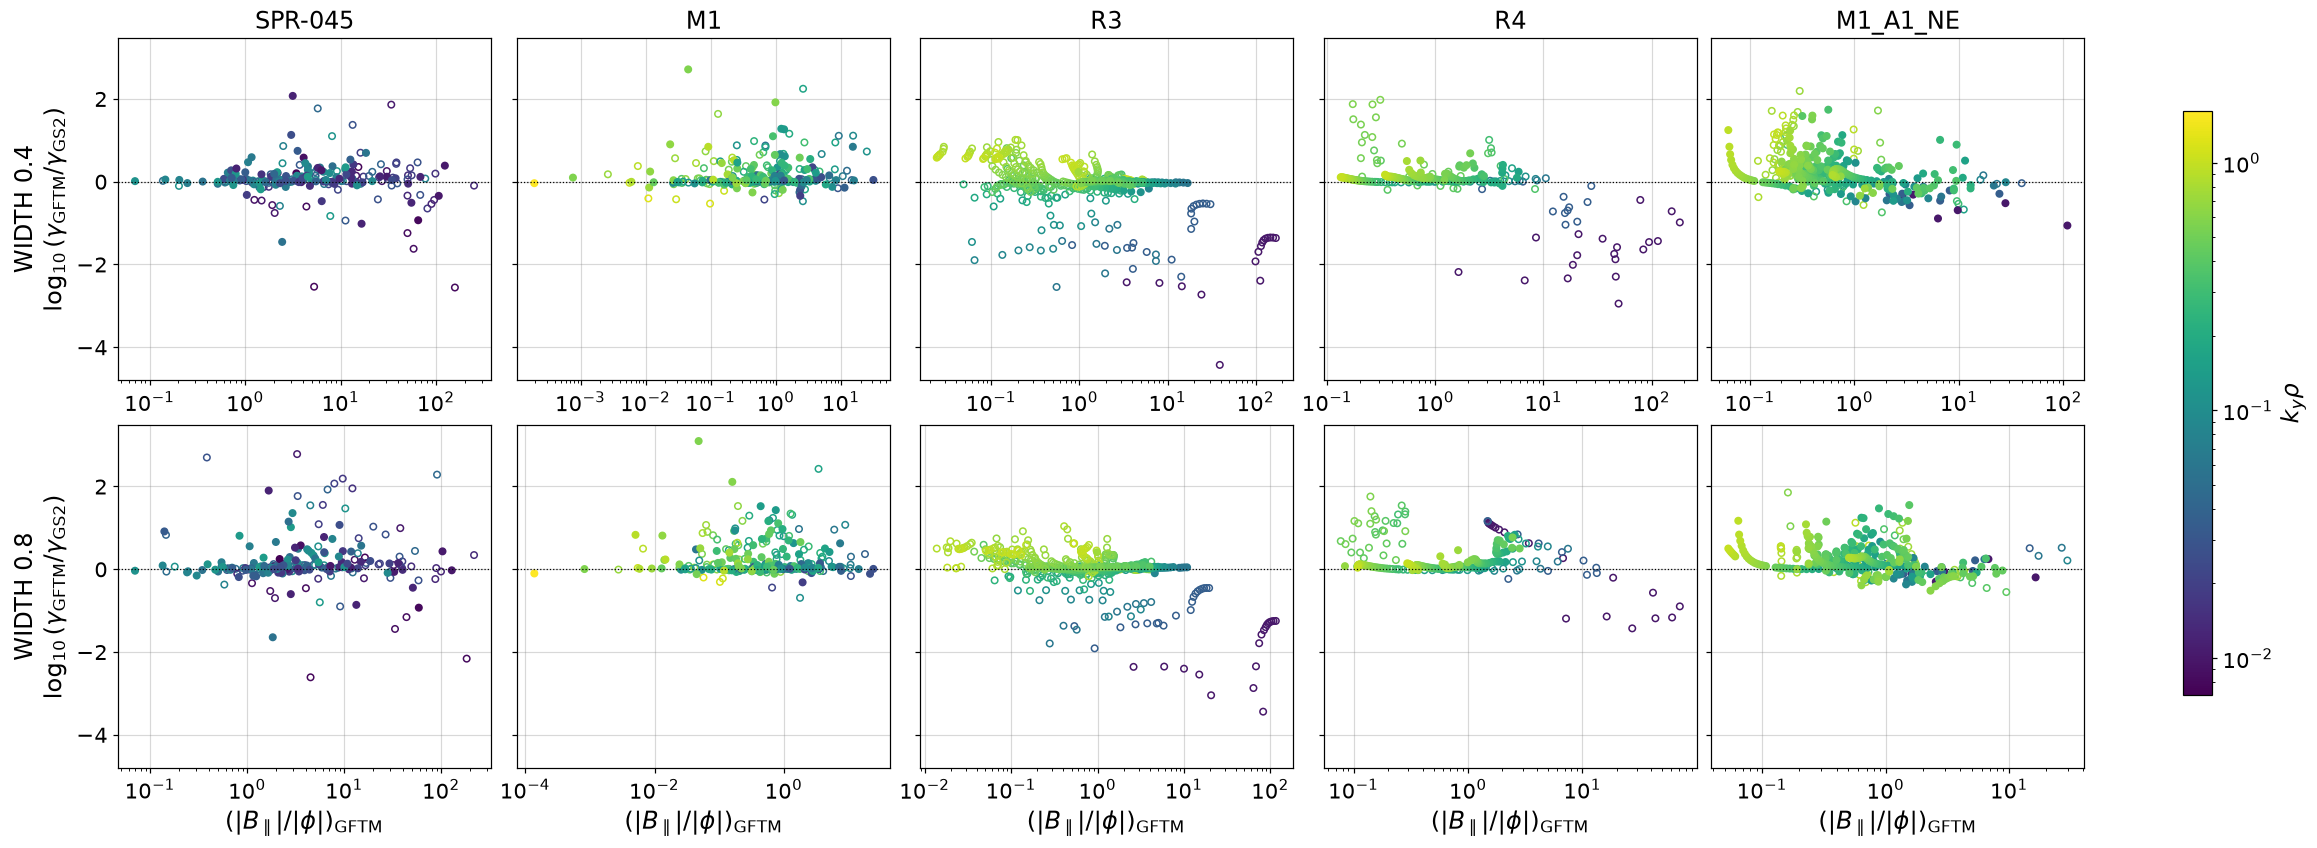

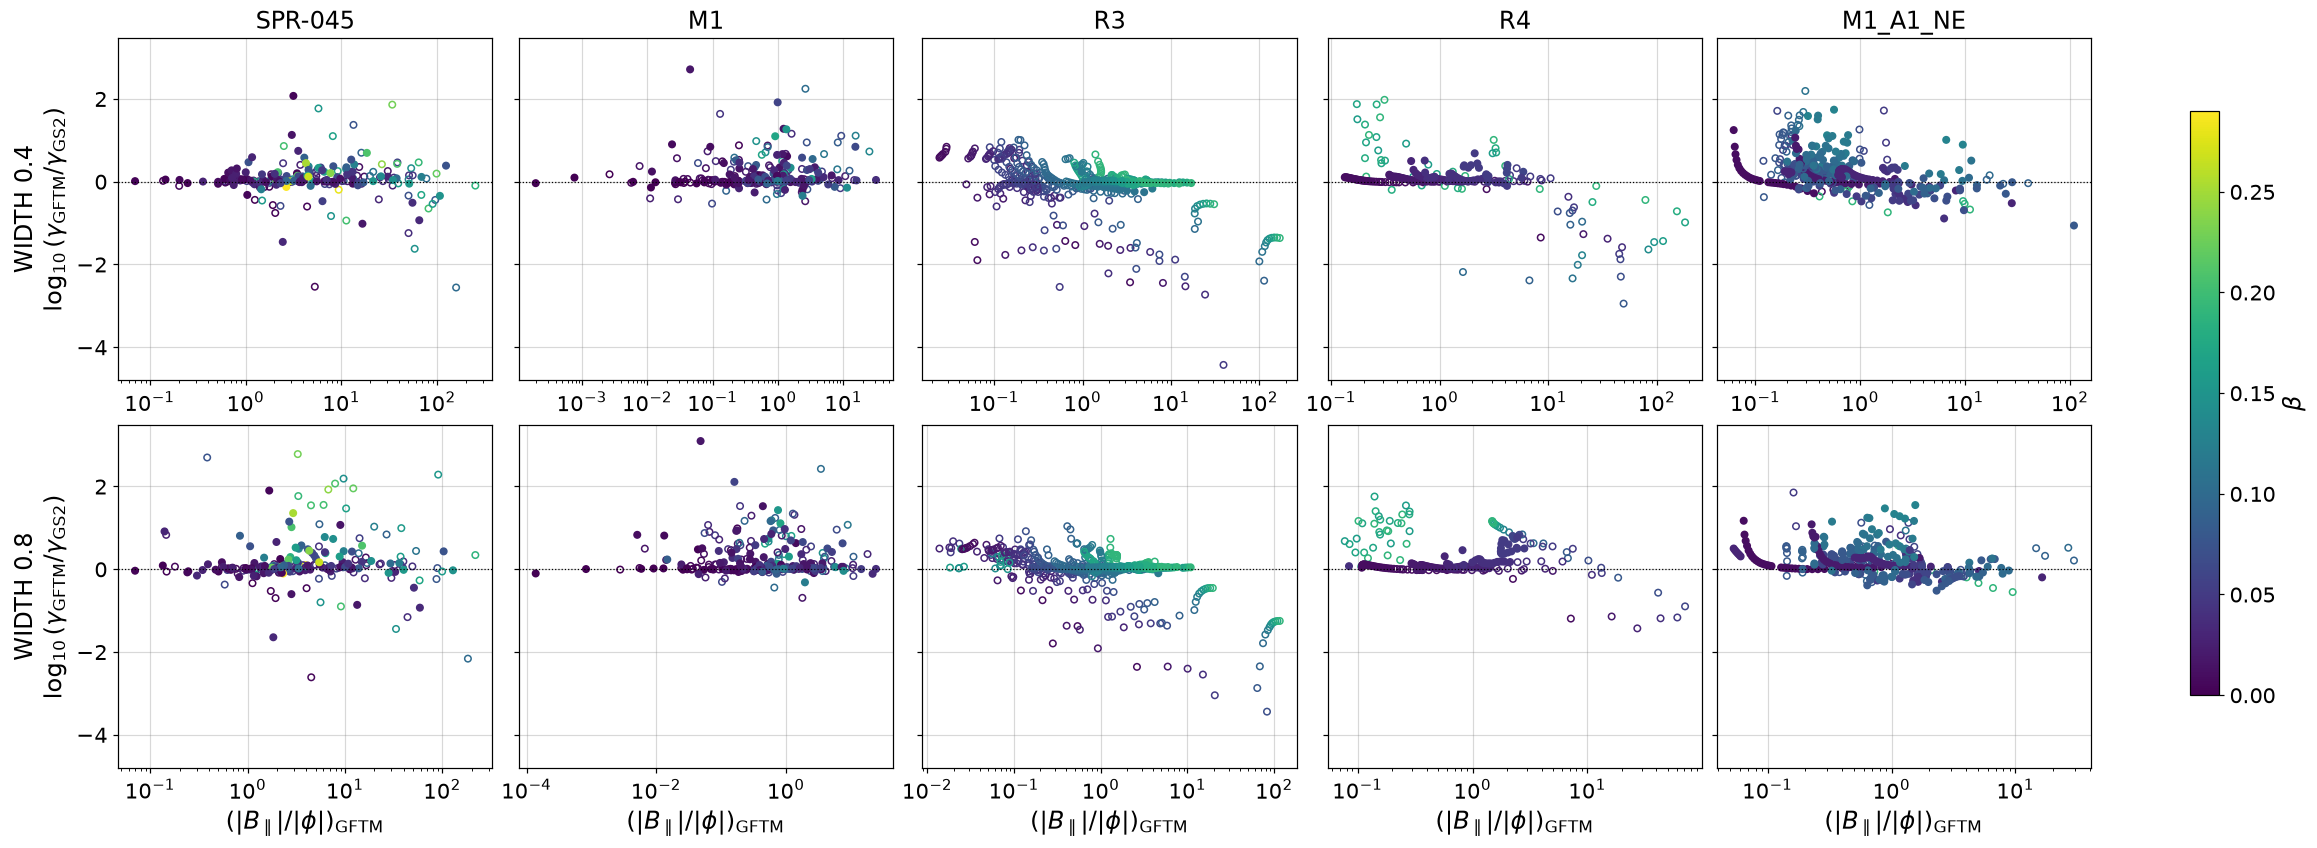

In [4]:
def scatter_grid(x, colour, cnorm, clabel, xlabel, fname):
    fig, axes = plt.subplots(len(widths), len(databases), figsize=(4.2 * len(databases), 3.8 * len(widths)), sharey=True,
                             squeeze=False)
    for i, w in enumerate(widths):
        for j, db in enumerate(databases):
            ax, df = axes[i, j], cases[(cases.width == w) & (cases.db == db) & cases.e.notna()]
            for kbm in (False, True):   # hollow = not GS2-KBM, filled = GS2-KBM
                p = df[df.kbm == kbm]
                rgba = plt.cm.viridis(cnorm(colour(p).values))
                ax.scatter(x(p), p.e, s=18, marker="o", edgecolors=rgba, facecolors=rgba if kbm else "none")
            ax.axhline(0, color="k", lw=0.8, ls=":", marker="none")
            ax.xaxis.set_minor_formatter(NullFormatter())
            ax.set_xscale("log")
            ax.tick_params(labelsize=fs_tick)
            if i == 0:
                ax.set_title(db, fontsize=fs_title)
            if i == len(widths) - 1:
                ax.set_xlabel(xlabel, fontsize=fs_label)
        axes[i, 0].set_ylabel(rf"WIDTH {w}" + "\n" + r"$\log_{10}(\gamma_{\rm GFTM}/\gamma_{\rm GS2})$", fontsize=fs_label)
    cb = fig.colorbar(plt.cm.ScalarMappable(norm=cnorm, cmap="viridis"), ax=axes, shrink=0.8)
    cb.set_label(clabel, fontsize=fs_label)
    cb.ax.tick_params(labelsize=fs_tick)
    fig.savefig(plot_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()


ky_norm = LogNorm(cases.ky.min(), cases.ky.max())
rlab = r"$(|B_\parallel|/|\phi|)_{\rm GFTM}$"
scatter_grid(lambda p: p.r_gftm, lambda p: p.ky, ky_norm, r"$k_y\rho$", rlab, "fig1_e_vs_rgftm_ky.png")
scatter_grid(lambda p: p.r_gftm, lambda p: p.beta, Normalize(0, cases.beta.max()), r"$\beta$", rlab, "fig1b_e_vs_rgftm_beta.png")

## Step 3: the ky dependence of R on same-mode cases
Fit log10 R = a_db + p·log10 ky per database, and pooled with one intercept per database. 95% CI from the slope's standard
error (t distribution). Then the residual scatter for the fixed exponents p = −1 (the 38e9.9 reading) and −2 (betasig's 1/ky²).

In [5]:
def fit(df, col="R"):
    "slope p, 95% CI half-width, and residual rms of log10(col) vs log10(ky) with one intercept per database"
    x, y = np.log10(df.ky.values), np.log10(df[col].values)
    G = pd.get_dummies(df.db).values.astype(float)
    A = np.column_stack([x, G])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    res = y - A @ coef
    dof = len(y) - A.shape[1]
    cov = np.linalg.inv(A.T @ A) * (res @ res) / dof
    return coef[0], stats.t.ppf(0.975, dof) * np.sqrt(cov[0, 0]), np.sqrt(res @ res / dof)


def rms_fixed(df, p, col="R"):
    "residual rms of log10(col * ky^-p) about each database's mean: how well a fixed power collapses R"
    z = np.log10(df[col]) - p * np.log10(df.ky)
    return np.sqrt(((z - z.groupby(df.db).transform("mean")) ** 2).mean())


fits = []
for w in widths:
    S = cases[(cases.width == w) & cases.same]
    for col in ("R", "R2"):
        for db, df in [*S.groupby("db", sort=False), ("pooled", S)]:
            if df.ky.nunique() < 3:
                continue
            p, ci, rms = fit(df, col)
            fits.append(dict(width=w, field=col, db=db, n=len(df), p=p, ci=ci, rms_fit=rms, rms_p0=rms_fixed(df, 0, col),
                             rms_pm1=rms_fixed(df, -1, col), rms_pm2=rms_fixed(df, -2, col),
                             medlogRky=np.median(np.log10(df[col] * df.ky))))
fits = pd.DataFrame(fits)
print(fits.round(3).to_string())

    width field        db    n      p     ci  rms_fit  rms_p0  rms_pm1  rms_pm2  medlogRky
0     0.4     R   SPR-045  125 -1.071  0.131    0.234   0.411    0.233    0.375      0.273
1     0.4     R        M1  148 -1.036  0.054    0.132   0.429    0.132    0.402      0.297
2     0.4     R        R3  273 -1.065  0.060    0.137   0.318    0.137    0.287      0.320
3     0.4     R        R4  142 -1.059  0.032    0.059   0.329    0.061    0.294      0.312
4     0.4     R  M1_A1_NE  114 -1.100  0.205    0.336   0.472    0.335    0.431      0.255
5     0.4     R    pooled  802 -1.061  0.041    0.186   0.382    0.186    0.349      0.305
6     0.4    R2   SPR-045  125 -1.083  0.135    0.242   0.419    0.242    0.377      0.129
7     0.4    R2        M1  148 -0.995  0.055    0.133   0.414    0.132    0.418      0.201
8     0.4    R2        R3  273 -1.054  0.051    0.115   0.307    0.116    0.280      0.179
9     0.4    R2        R4  142 -0.942  0.024    0.043   0.291    0.047    0.326      0.245

Figure 2: R against ky on same-mode cases, with the per-database fitted slope (solid) and a 1/ky line (dashed) through the median.

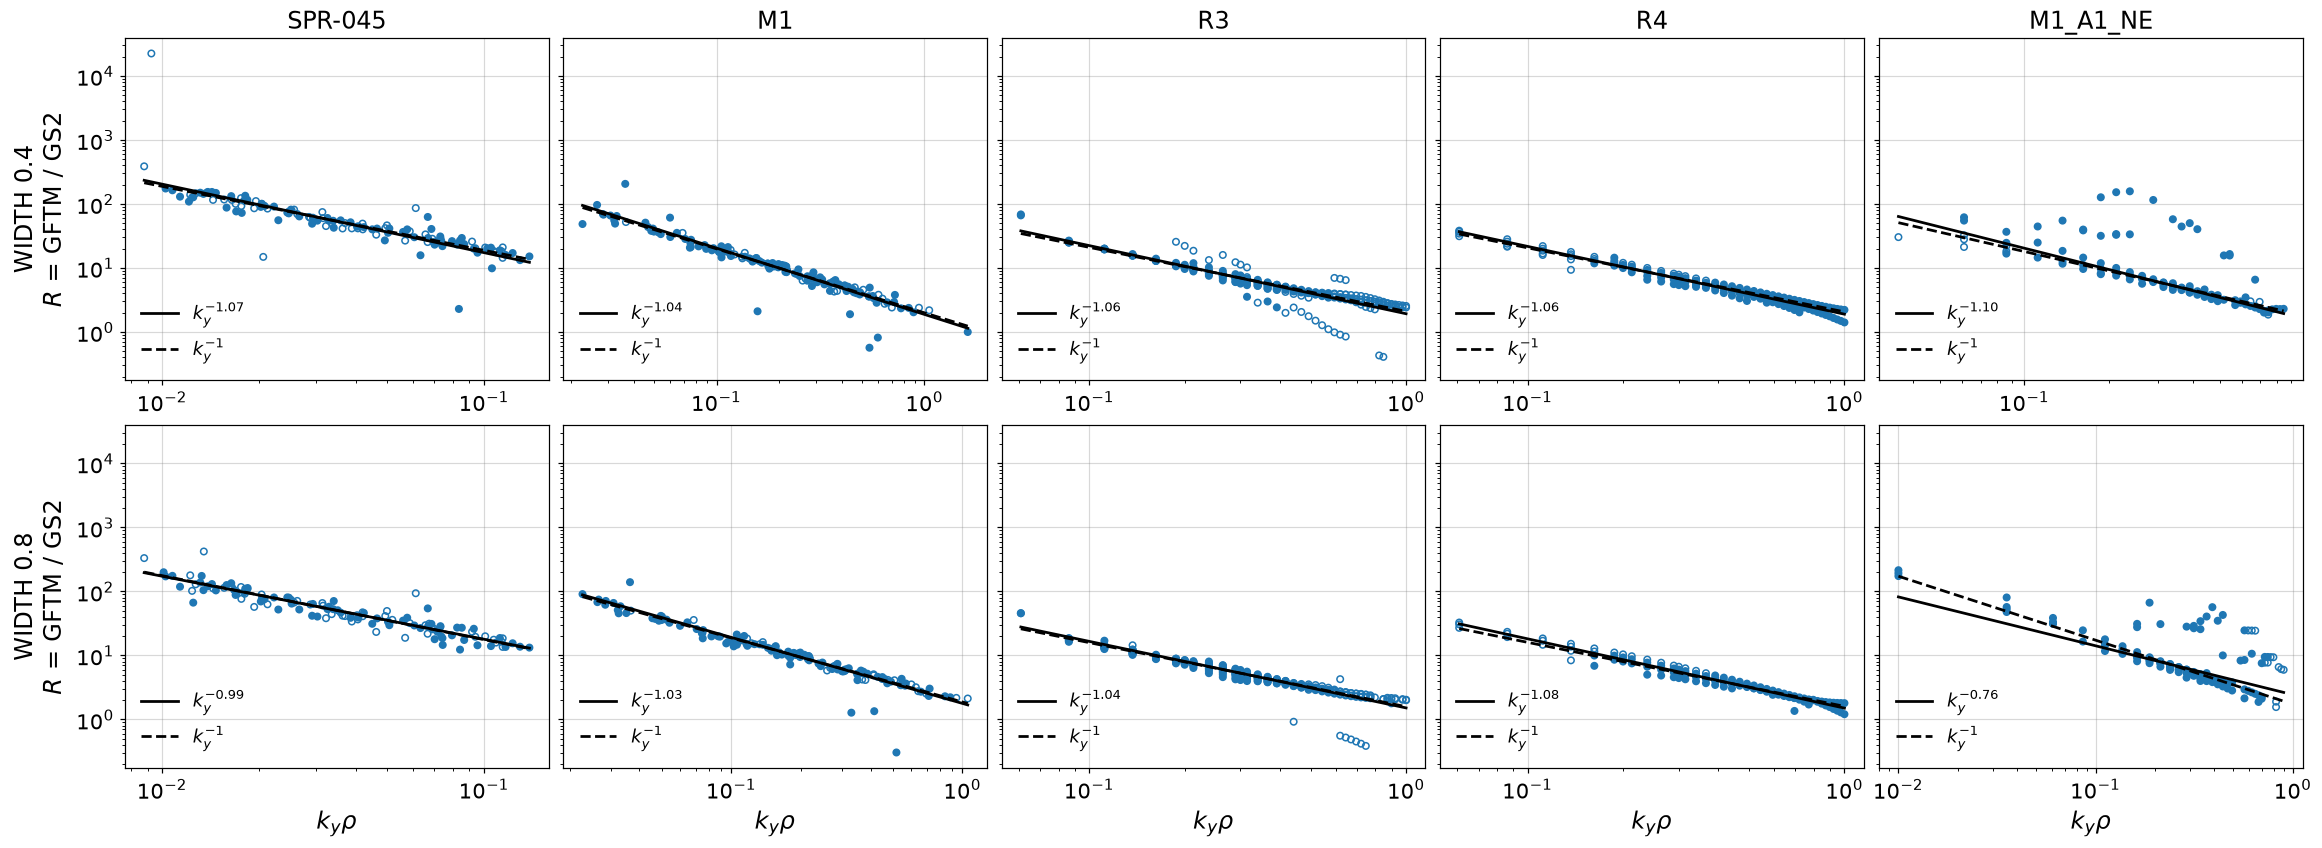

In [6]:
fig, axes = plt.subplots(len(widths), len(databases), figsize=(4.2 * len(databases), 3.8 * len(widths)), sharey=True, squeeze=False)
for i, w in enumerate(widths):
    for j, db in enumerate(databases):
        ax, df = axes[i, j], cases[(cases.width == w) & (cases.db == db) & cases.same]
        ax.scatter(df.ky, df.R, s=18, c=np.where(df.kbm, "C0", "none"), edgecolors="C0")
        f = fits[(fits.width == w) & (fits.db == db) & (fits.field == "R")]
        if len(f) and len(df):
            k = np.geomspace(df.ky.min(), df.ky.max())
            a = np.median(np.log10(df.R) - f.p.iloc[0] * np.log10(df.ky))
            ax.plot(k, 10 ** a * k ** f.p.iloc[0], "k-", marker="none", label=rf"$k_y^{{{f.p.iloc[0]:.2f}}}$")
            a1 = np.median(np.log10(df.R * df.ky))
            ax.plot(k, 10 ** a1 / k, "k--", marker="none", label=r"$k_y^{-1}$")
            ax.legend(fontsize=fs_legend, loc="lower left")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.tick_params(labelsize=fs_tick)
        if i == 0:
            ax.set_title(db, fontsize=fs_title)
        if i == len(widths) - 1:
            ax.set_xlabel(r"$k_y\rho$", fontsize=fs_label)
    axes[i, 0].set_ylabel(rf"WIDTH {w}" + "\n" + r"$R$ = GFTM / GS2", fontsize=fs_label)
fig.savefig(plot_dir / "fig2_R_vs_ky_samemode.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 3b: does the ky correction remove the large-B∥ / bad-γ association?
Corrected GFTM ratio r_GFTM·ky (the 1/ky hypothesis) and r_GFTM·ky^(−p_pooled) (fitted). Repeat the step-2 selection.

In [7]:
p_pooled = {w: float(fits[(fits.width == w) & (fits.db == "pooled") & (fits.field == "R")].p.iloc[0]) for w in widths}
print("pooled same-mode exponent p:", {w: round(p, 3) for w, p in p_pooled.items()})
cases["r_gftm_ky"] = cases.r_gftm * cases.ky
cases["R_ky"] = cases.R * cases.ky
cases["r_gftm_kyp"] = cases.r_gftm * cases.ky ** -cases.width.map(p_pooled)
cases["R_kyp"] = cases.R * cases.ky ** -cases.width.map(p_pooled)
sel_corr = selection_table(["r_gftm_ky", "R_ky", "r_gftm_kyp", "R_kyp"])
print(sel_corr.round(3).to_string())

# collapse check on the same-mode population: spread of log10 R before and after
for w in widths:
    S = cases[(cases.width == w) & cases.same]
    print(f"WIDTH {w}: same-mode n={len(S)} | log10 R median {np.log10(S.R).median():.2f}, IQR {np.log10(S.R).quantile(.75) - np.log10(S.R).quantile(.25):.2f}"
          f" | log10 R*ky median {np.log10(S.R_ky).median():.2f}, IQR {np.log10(S.R_ky).quantile(.75) - np.log10(S.R_ky).quantile(.25):.2f}")

pooled same-mode exponent p: {0.4: -1.061, 0.8: -0.974}
                                      n  e_top  e_rest  dg_top  dg_rest    rho
unstable 0.4 SPR-045  r_gftm_ky   220.0  0.053   0.026   0.004    0.013  0.115
                      R_ky        220.0 -0.057   0.052   0.008    0.009 -0.464
                      r_gftm_kyp  220.0  0.066   0.025   0.004    0.013  0.118
                      R_kyp       220.0 -0.054   0.052   0.008    0.010 -0.447
         0.8 SPR-045  r_gftm_ky   220.0  0.113   0.036   0.006    0.014  0.244
                      R_ky        220.0 -0.053   0.060   0.026    0.011 -0.523
                      r_gftm_kyp  220.0  0.113   0.036   0.006    0.014  0.244
                      R_kyp       220.0 -0.053   0.059   0.014    0.011 -0.529
         0.4 M1       r_gftm_ky   252.0  0.071   0.023   0.027    0.034  0.195
                      R_ky        252.0  0.130   0.026   0.034    0.030 -0.167
                      r_gftm_kyp  252.0  0.082   0.022   0.028    0.033  0.

Figure 3: e against the ky-corrected GFTM ratio r_GFTM·ky (all GS2-unstable cases, filled = GS2-KBM), coloured by ky.

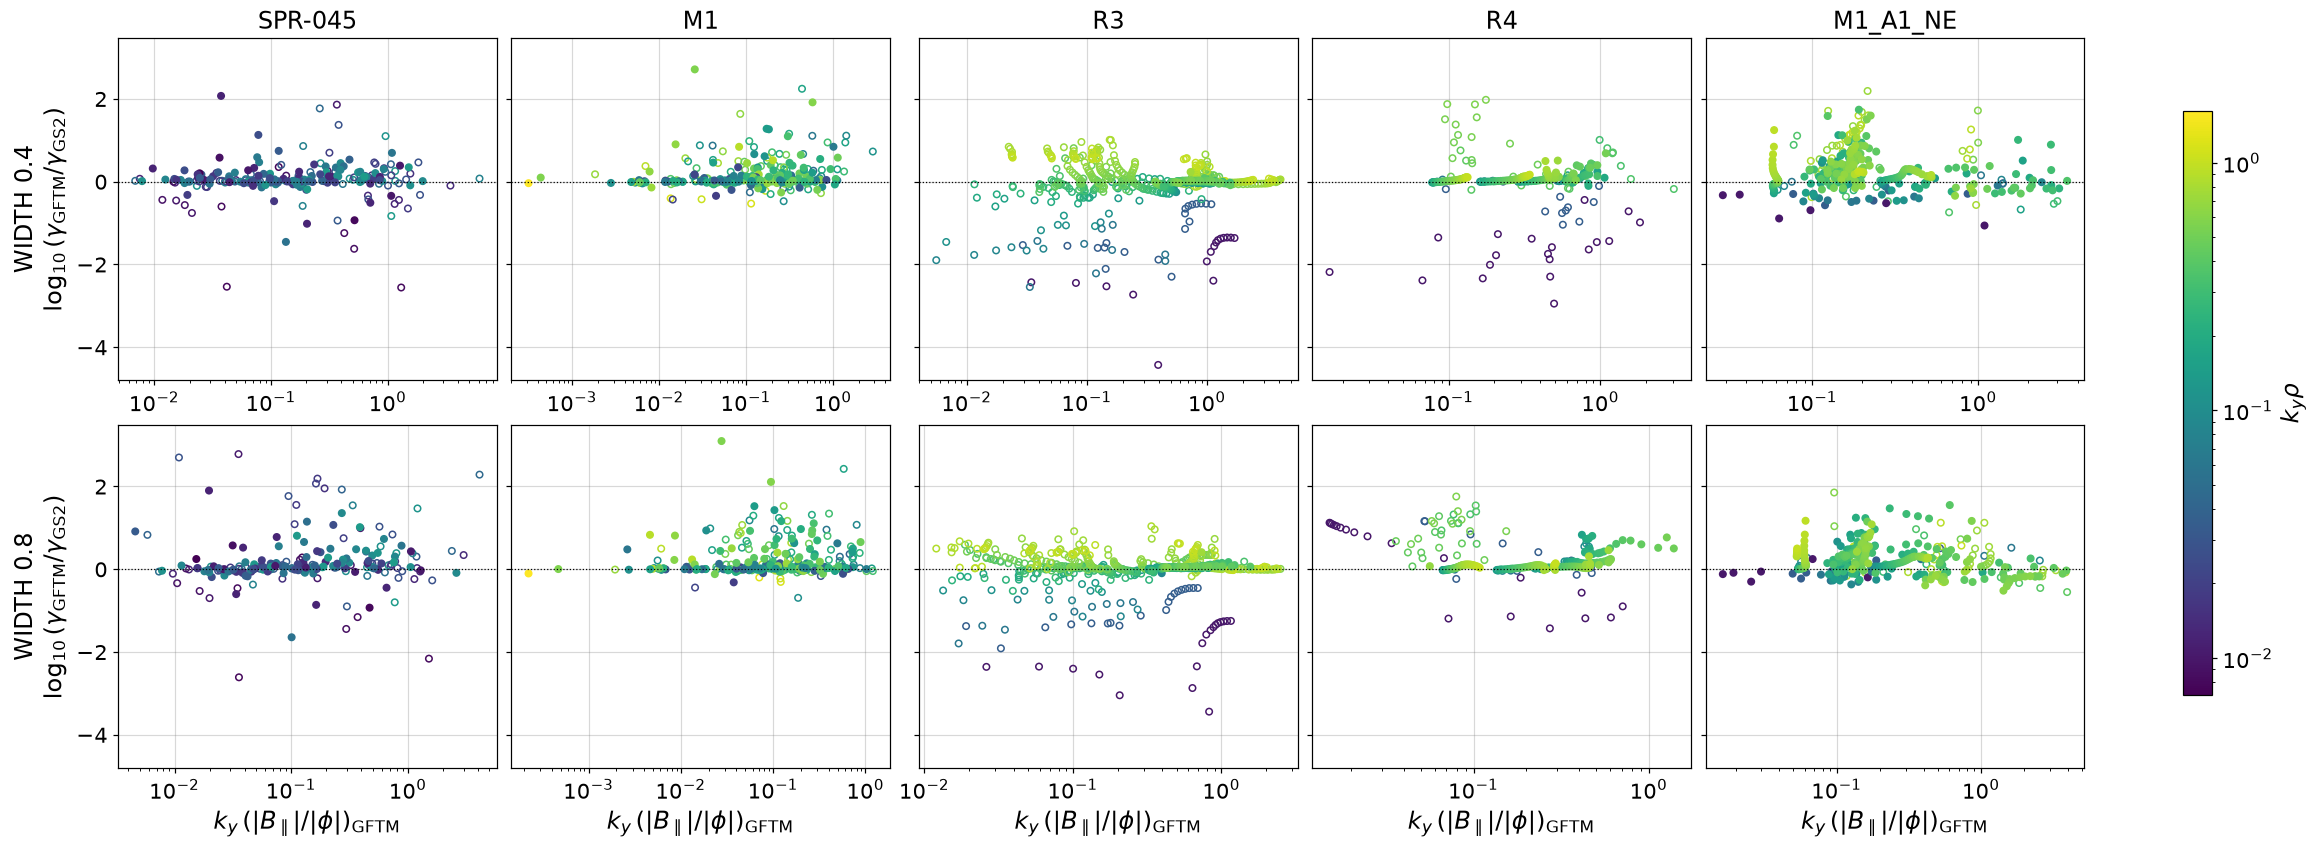

In [8]:
scatter_grid(lambda p: p.r_gftm * p.ky, lambda p: p.ky, ky_norm, r"$k_y\rho$",
             r"$k_y\,(|B_\parallel|/|\phi|)_{\rm GFTM}$", "fig3_e_vs_rgftm_times_ky.png")

## Pooled summary (all databases, per WIDTH)

In [9]:
summary = []
for w in widths:
    for pop, sel in {"unstable": cases.e.notna(), "KBM": cases.e.notna() & cases.kbm}.items():
        df = cases[(cases.width == w) & sel]
        for col in ("r_gftm", "R", "r_gftm_ky", "R_ky"):
            big = df[col] >= df.groupby("db")[col].transform(lambda c: c.quantile(top))   # top quartile within each database
            summary.append(dict(width=w, pop=pop, ratio=col, n=len(df), n_top=int(big.sum()),
                                e_top=df.e[big].median(), e_rest=df.e[~big].median(),
                                frac_over2_top=(df.e[big] > np.log10(2)).mean(), frac_over2_rest=(df.e[~big] > np.log10(2)).mean()))
print(pd.DataFrame(summary).round(3).to_string())

    width       pop      ratio     n  n_top  e_top  e_rest  frac_over2_top  frac_over2_rest
0     0.4  unstable     r_gftm  1653    415 -0.023   0.040           0.111            0.228
1     0.4  unstable          R  1653    415 -0.087   0.048           0.080            0.238
2     0.4  unstable  r_gftm_ky  1653    415  0.012   0.020           0.152            0.214
3     0.4  unstable       R_ky  1653    415 -0.084   0.036           0.149            0.215
4     0.4       KBM     r_gftm   849    215 -0.017   0.037           0.144            0.159
5     0.4       KBM          R   849    215 -0.020   0.049           0.093            0.177
6     0.4       KBM  r_gftm_ky   849    215  0.033   0.022           0.158            0.155
7     0.4       KBM       R_ky   849    215 -0.030   0.047           0.116            0.169
8     0.8  unstable     r_gftm  1654    415  0.031   0.062           0.169            0.263
9     0.8  unstable          R  1654    415 -0.019   0.084           0.099      